In [2]:
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, mean_squared_error, mean_absolute_error, classification_report, average_precision_score
import xgboost as xgb
import matplotlib.pyplot as plt
import networkx as nx

from tqdm import tqdm
pd.set_option('display.max_columns', 5000)

In [3]:
def calculate_netkde_for_month(df_month, cols_to_smooth, bandwidth=150):
    """
    Applies Network Kernel Density Estimation (NetKDE)
    Distributes snapped crime points across neighboring streets using a Gaussian kernel.
    """
    G = nx.Graph()
    for _, row in df_month.iterrows():
        G.add_edge(row['u'], row['v'], edge_id=row['edge_id'], weight=row['length'])
        
    smoothed_scores = {row['edge_id']: {col: 0.0 for col in cols_to_smooth} for _, row in df_month.iterrows()}
    
    event_mask = (df_month[cols_to_smooth] > 0).any(axis=1)
    event_edges = df_month[event_mask]
    
    for _, source_row in event_edges.iterrows():
        source_u = source_row['u']
        
        ego_graph = nx.ego_graph(G, source_u, radius=bandwidth, distance='weight')
        
        try:
            path_lengths = nx.single_source_dijkstra_path_length(ego_graph, source_u, weight='weight')
        except nx.NetworkXNoPath:
            path_lengths = {source_u: 0.0}
        
        sigma = bandwidth / 3.0
        
        for u, v, data in ego_graph.edges(data=True):
            dist_u = path_lengths.get(u, bandwidth)
            dist_v = path_lengths.get(v, bandwidth)
            dist = min(dist_u, dist_v)
            
            decay_weight = np.exp(-0.5 * (dist / sigma) ** 2)
            
            for col in cols_to_smooth:
                source_val = source_row[col]
                if source_val > 0:
                    smoothed_scores[data['edge_id']][col] += (source_val * decay_weight)
            
    for col in cols_to_smooth:
        df_month[col] = df_month['edge_id'].map(lambda eid: smoothed_scores[eid][col])
    
    return df_month

def apply_temporal_netkde(df_long, cols_to_smooth, bandwidth=150):
    """
    Wraps the NetKDE function to apply it month-by-month to avoid data leakage.
    """
    print(f"Applying Spatial NetKDE (Bandwidth: {bandwidth}m) across {len(cols_to_smooth)} features...")
    smoothed_dfs = []
    
    grouped = df_long.groupby('year_month')
    
    for year_month, group in tqdm(grouped, desc="Smoothing Months", unit="month"):
        smoothed_group = calculate_netkde_for_month(group.copy(), cols_to_smooth, bandwidth=bandwidth)
        smoothed_dfs.append(smoothed_group)
        
    return pd.concat(smoothed_dfs, ignore_index=True)

In [4]:
def format_ml(df):
    """
    Transforms a wide-format crime dataset into a long format with lag features for ML.
    """
    
    # 1. Isolate static features
    static_features = [
        'edge_id', 'u', 'u_lat', 'u_lng', 'v', 'v_lat', 'v_lng', 
        'key', 'name', 'highway', 'length'
    ]
    df_static = df[static_features].copy()

    # 2. Isolating time series
    time_cols = [col for col in df.columns if pd.Series(col).str.contains(r'\d{4}_\d{2}$').any()]
    df_time = df[['edge_id'] + time_cols].copy()

    # 3. Condensing all time columns into 'metric' and 'value'
    df_melted = df_time.melt(id_vars='edge_id', var_name='metric_month', value_name='value')

    # 4. Split the melted column into a 'metric' and a 'year_month'
    # e.g., splits 'crime_count_2023_06' -> 'crime_count' and '2023_06'
    extract_regex = r'^(?P<metric>.*)_(?P<year_month>\d{4}_\d{2})$'
    df_melted[['metric', 'year_month']] = df_melted['metric_month'].str.extract(extract_regex)
    df_melted = df_melted.drop(columns=['metric_month'])

    # 5. Pivot: Push the metrics back into their own distinct columns
    df_long = df_melted.pivot(
        index=['edge_id', 'year_month'], 
        columns='metric', 
        values='value'
    ).reset_index()

    # 6. Sort chronologically
    df_long = df_long.sort_values(by=['edge_id', 'year_month'])

    # 7. Engineer Lag Features (1, 2 and 3 months)
    lags = [1, 2, 3]
    metrics_to_lag = ['crime_count', 'crime_severity_sum', 'stop_search_count']

    for metric in metrics_to_lag:
        for lag in lags:
            # Groupby ensures a street only looks at its own history, not the street above it
            df_long[f'{metric}_lag_{lag}'] = df_long.groupby('edge_id')[metric].shift(lag)

    # 8. Drop rows with NaNs caused by the shift (first 3 months)
    df_long = df_long.dropna(subset=[f'crime_count_lag_{lag}' for lag in lags]).reset_index(drop=True)

    # 9. Merge the static street metadata back in
    final_df = pd.merge(df_long, df_static, on='edge_id', how='left')

    # 10. Rename current month metrics to 'target'
    final_df = final_df.rename(columns={
        'crime_count': 'target_crime_count',
        'crime_severity_sum': 'target_crime_severity',
        'stop_search_count': 'target_stop_search'
    })
    # 11. Apply Network KDE Smoothing
    # Application is done on all relevant columns
    features_to_smooth = [
        'target_crime_count', 
        'target_crime_severity', 
        'target_stop_search',
        'crime_count_lag_1', 
        'crime_count_lag_2', 
        'crime_count_lag_3', 
        'crime_severity_sum_lag_1', 
        'crime_severity_sum_lag_2', 
        'crime_severity_sum_lag_3',
        'stop_search_count_lag_1', 
        'stop_search_count_lag_2', 
        'stop_search_count_lag_3'
    ]
    
    final_df = apply_temporal_netkde(final_df, cols_to_smooth=features_to_smooth, bandwidth=150)
    

    return final_df



In [5]:
def train_crime_model(ml_ready_df):
    """
    Trains a Cost-Sensitive XGBoost Classifier for street safety prediction.
    """
    # 1. Define the chronological cutoff 
    cutoff_month = '2026_03'
    
    # 2. Split into Train (Past) and Test (Future)
    train_df = ml_ready_df[ml_ready_df['year_month'] < cutoff_month].copy()
    test_df = ml_ready_df[ml_ready_df['year_month'] >= cutoff_month].copy()
    
    print(f"Training on {len(train_df)} records (Before {cutoff_month})")
    print(f"Testing on {len(test_df)} records ({cutoff_month} onwards)")

    # 3. Binarize the Target for Classification
    # Any street with > 0 crimes in a month is flagged as 'At Risk' (1)
    train_df['is_at_risk'] = (train_df['target_crime_count'] > 0).astype(int)
    test_df['is_at_risk'] = (test_df['target_crime_count'] > 0).astype(int)
    target_col = 'is_at_risk'
    
    # 4. Define Features (X)
    cols_to_drop = [
        'edge_id', 'year_month', 'name', 'u', 'v', 'key', 
        'target_crime_count', 'target_crime_severity', 'target_stop_search',
        'is_at_risk' 
    ]
    
    # Convert 'highway' to a Pandas category dtype 
    train_df['highway'] = train_df['highway'].astype('category')
    test_df['highway'] = test_df['highway'].astype('category')
    
    X_train = train_df.drop(columns=cols_to_drop)
    y_train = train_df[target_col]
    
    X_test = test_df.drop(columns=cols_to_drop)
    y_test = test_df[target_col]

    # 5. Calculate Cost-Sensitive Weight (scale_pos_weight)
    negative_class_count = (y_train == 0).sum()
    positive_class_count = (y_train == 1).sum()
    spw = negative_class_count / positive_class_count
    
    print(f"\nClass Imbalance Ratio (Safe vs At Risk): {spw:.2f}")

    # 6. Initialize XGBoost Classifier
    model = xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        enable_categorical=True,
        random_state=42,
        early_stopping_rounds=50,
        scale_pos_weight=spw,         # Applies the cost-sensitive penalty
        objective='binary:logistic',  # Outputs probabilities
        eval_metric='aucpr'           # PR-AUC metric for severe imbalance
    )

    # 7. Train the model
    print("Training Cost-Sensitive XGBoost Classifier...")
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=50 
    )

    # 8. Evaluate the predictions
    # Predict probabilities for the 'At Risk' class (Class 1)
    probabilities = model.predict_proba(X_test)[:, 1]
    
    # Predict hard classes (0 or 1) based on a 0.5 threshold
    class_predictions = model.predict(X_test)
    
    pr_auc = average_precision_score(y_test, probabilities)
    print(f"\nPrecision-Recall AUC (PR-AUC): {pr_auc:.3f}")
    print("\nClassification Report:")
    print(classification_report(y_test, class_predictions, target_names=["Safe (0)", "At Risk (1)"]))
    
    return model, X_train.columns

In [6]:
def feature_importance(model, X_train):
    """
    Extracts feature importance and displays in a bar chart.
    """
    # 1. Visual Plot: Using XGBoost's built-in plotter
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # We use importance_type='gain' because it measures predictive power
    xgb.plot_importance(
        model, 
        importance_type='gain', 
        max_num_features=15, # Only show the top 15 features
        ax=ax, 
        height=0.5,
        color='steelblue'
    )
    plt.title("Top 15 Most Predictive Features (by Information Gain)")
    plt.show()

    # 2. Raw Data: Extracting into a Pandas DataFrame
    importance_dict = model.get_booster().get_score(importance_type='gain')
    
    importance_df = pd.DataFrame({
        'Feature': list(importance_dict.keys()),
        'Gain': list(importance_dict.values())
    })
    
    # Sort from most to least important
    importance_df = importance_df.sort_values(by='Gain', ascending=False).reset_index(drop=True)
    
    print("\nFeature Importance Rankings:")
    print(importance_df.head(15))
    
    return importance_df

In [7]:
def predict_and_map_to_nodes(ml_ready_df, model, feature_columns, latest_month='2026_05'):
    """
    Predicts crime probability for the next month, calculates safety cost, and maps to OSM nodes.
    """
    if isinstance(feature_columns, pd.DataFrame):
        feature_columns = feature_columns.columns.tolist()
    elif hasattr(feature_columns, 'tolist'):
        feature_columns = feature_columns.tolist()
        
    # ==========================================
    # 1. Prepare Future Data (Shift Lags Forward)
    # ==========================================
    latest_data = ml_ready_df[ml_ready_df['year_month'] == latest_month].copy()
    future_data = latest_data.copy()
    
    # Shift the lags forward by 1 month
    future_data['crime_count_lag_1'] = latest_data['target_crime_count']
    future_data['crime_count_lag_2'] = latest_data['crime_count_lag_1']
    future_data['crime_count_lag_3'] = latest_data['crime_count_lag_2']
    
    future_data['crime_severity_sum_lag_1'] = latest_data['target_crime_severity']
    future_data['crime_severity_sum_lag_2'] = latest_data['crime_severity_sum_lag_1']
    future_data['crime_severity_sum_lag_3'] = latest_data['crime_severity_sum_lag_2']
    
    future_data['stop_search_count_lag_1'] = latest_data['target_stop_search']
    future_data['stop_search_count_lag_2'] = latest_data['stop_search_count_lag_1']
    future_data['stop_search_count_lag_3'] = latest_data['stop_search_count_lag_2']
    
    if 'highway' in future_data.columns:
        future_data['highway'] = future_data['highway'].astype('category')
        
    X_future = future_data[feature_columns]

    # ==========================================
    # 2. Generate Probabilities
    # ==========================================
    print("Predicting future risk probabilities...")
    # Extract the probability specifically for Class 1 ('At Risk')
    future_data['risk_probability'] = model.predict_proba(X_future)[:, 1]

    # ==========================================
    # 3. Calculate "Safety Cost" for the Edges
    # ==========================================
    # Directly scale the probability (0.0 - 1.0) to a 1.0 - 10.0 scale
    future_data['safety_tag_value'] = 1 + (future_data['risk_probability'] * 9)

    # ==========================================
    # 4. Map Edge Costs onto OSM Nodes (u and v)
    # ==========================================
    u_nodes = future_data[['u', 'u_lat', 'u_lng', 'safety_tag_value']].rename(
        columns={'u': 'node_id', 'u_lat': 'lat', 'u_lng': 'lng', 'safety_tag_value': 'cost'}
    )
    v_nodes = future_data[['v', 'v_lat', 'v_lng', 'safety_tag_value']].rename(
        columns={'v': 'node_id', 'v_lat': 'lat', 'v_lng': 'lng', 'safety_tag_value': 'cost'}
    )
    
    all_nodes = pd.concat([u_nodes, v_nodes])
    
    node_safety_df = all_nodes.groupby('node_id').agg(
        node_safety_cost=('cost', 'mean'),
        lat=('lat', 'first'),
        lng=('lng', 'first')
    ).reset_index()

    node_safety_df = node_safety_df.sort_values(by='node_safety_cost', ascending=False).reset_index(drop=True)
    
    print("\nTop 5 Highest Risk Nodes:")
    print(node_safety_df.head())
    
    return future_data, node_safety_df

In [8]:
def osm_tag_mapping(future_edges_df):
    """
    Creates a clean mapping of OSM Way IDs to Safety Costs.
    """
    df = future_edges_df.copy()
    
    # We round the safety cost to an integer (1-10) to make the Valhalla Lua costing easier
    df['safety_tag_value'] = df['safety_tag_value'].round().astype(int)
    
    # Isolate just the OSM ID and the new Tag Value
    osm_tags = df[['edge_id', 'safety_tag_value']].drop_duplicates()
    
    osm_tags.to_csv('osm_safety_tags.csv', index=False)
    print("Saved OSM Tag mapping. Use this to tag your .osm.pbf file.")

In [9]:
df = pd.read_csv('edge_features.csv')

df_ml = format_ml(df)

Applying Spatial NetKDE (Bandwidth: 150m) across 12 features...


Smoothing Months: 100%|██████████| 33/33 [01:38<00:00,  2.98s/month]


In [10]:
df.head()

,edge_id,u,u_lat,u_lng,v,v_lat,v_lng,key,name,highway,length,crime_count,crime_severity_sum,crime_perceived_risk_sum,stop_search_count,crime_count_2023_06,crime_count_2023_07,crime_count_2023_08,crime_count_2023_09,crime_count_2023_10,crime_count_2023_11,crime_count_2023_12,crime_count_2024_01,crime_count_2024_02,crime_count_2024_03,crime_count_2024_04,crime_count_2024_05,crime_count_2024_06,crime_count_2024_07,crime_count_2024_08,crime_count_2024_09,crime_count_2024_10,crime_count_2024_11,crime_count_2024_12,crime_count_2025_01,crime_count_2025_02,crime_count_2025_03,crime_count_2025_04,crime_count_2025_05,crime_count_2025_06,crime_count_2025_07,crime_count_2025_08,crime_count_2025_09,crime_count_2025_10,crime_count_2025_11,crime_count_2025_12,crime_count_2026_01,crime_count_2026_02,crime_count_2026_03,crime_count_2026_04,crime_count_2026_05,crime_severity_sum_2023_06,crime_severity_sum_2023_07,crime_severity_sum_2023_08,crime_severity_sum_2023_09,crime_severity_sum_2023_10,crime_severity_sum_2023_11,crime_severity_sum_2023_12,crime_severity_sum_2024_01,crime_severity_sum_2024_02,crime_severity_sum_2024_03,crime_severity_sum_2024_04,crime_severity_sum_2024_05,crime_severity_sum_2024_06,crime_severity_sum_2024_07,crime_severity_sum_2024_08,crime_severity_sum_2024_09,crime_severity_sum_2024_10,crime_severity_sum_2024_11,crime_severity_sum_2024_12,crime_severity_sum_2025_01,crime_severity_sum_2025_02,crime_severity_sum_2025_03,crime_severity_sum_2025_04,crime_severity_sum_2025_05,crime_severity_sum_2025_06,crime_severity_sum_2025_07,crime_severity_sum_2025_08,crime_severity_sum_2025_09,crime_severity_sum_2025_10,crime_severity_sum_2025_11,crime_severity_sum_2025_12,crime_severity_sum_2026_01,crime_severity_sum_2026_02,crime_severity_sum_2026_03,crime_severity_sum_2026_04,crime_severity_sum_2026_05,crime_perceived_risk_sum_2023_06,crime_perceived_risk_sum_2023_07,crime_perceived_risk_sum_2023_08,crime_perceived_risk_sum_2023_09,crime_perceived_risk_sum_2023_10,crime_perceived_risk_sum_2023_11,crime_perceived_risk_sum_2023_12,crime_perceived_risk_sum_2024_01,crime_perceived_risk_sum_2024_02,crime_perceived_risk_sum_2024_03,crime_perceived_risk_sum_2024_04,crime_perceived_risk_sum_2024_05,crime_perceived_risk_sum_2024_06,crime_perceived_risk_sum_2024_07,crime_perceived_risk_sum_2024_08,crime_perceived_risk_sum_2024_09,crime_perceived_risk_sum_2024_10,crime_perceived_risk_sum_2024_11,crime_perceived_risk_sum_2024_12,crime_perceived_risk_sum_2025_01,crime_perceived_risk_sum_2025_02,crime_perceived_risk_sum_2025_03,crime_perceived_risk_sum_2025_04,crime_perceived_risk_sum_2025_05,crime_perceived_risk_sum_2025_06,crime_perceived_risk_sum_2025_07,crime_perceived_risk_sum_2025_08,crime_perceived_risk_sum_2025_09,crime_perceived_risk_sum_2025_10,crime_perceived_risk_sum_2025_11,crime_perceived_risk_sum_2025_12,crime_perceived_risk_sum_2026_01,crime_perceived_risk_sum_2026_02,crime_perceived_risk_sum_2026_03,crime_perceived_risk_sum_2026_04,crime_perceived_risk_sum_2026_05,stop_search_count_2023_06,stop_search_count_2023_07,stop_search_count_2023_08,stop_search_count_2023_09,stop_search_count_2023_10,stop_search_count_2023_11,stop_search_count_2023_12,stop_search_count_2024_01,stop_search_count_2024_02,stop_search_count_2024_03,stop_search_count_2024_04,stop_search_count_2024_05,stop_search_count_2024_06,stop_search_count_2024_07,stop_search_count_2024_08,stop_search_count_2024_09,stop_search_count_2024_10,stop_search_count_2024_11,stop_search_count_2024_12,stop_search_count_2025_01,stop_search_count_2025_02,stop_search_count_2025_03,stop_search_count_2025_04,stop_search_count_2025_05,stop_search_count_2025_06,stop_search_count_2025_07,stop_search_count_2025_08,stop_search_count_2025_09,stop_search_count_2025_10,stop_search_count_2025_11,stop_search_count_2025_12,stop_search_count_2026_01,stop_search_count_2026_02,stop_search_count_2026_03,stop_search_count_2026_04,stop_search_count_2026_05,crime_per_km,crime_severity_per_km,crime_avg_seve

In [11]:
model, X_train = train_crime_model(df_ml)

Training on 1065720 records (Before 2026_03)
Testing on 106572 records (2026_03 onwards)

Class Imbalance Ratio (Safe vs At Risk): 1.65
Training Cost-Sensitive XGBoost Classifier...
[0]	validation_0-aucpr:0.98658	validation_1-aucpr:0.98173
[50]	validation_0-aucpr:0.99188	validation_1-aucpr:0.98817
[100]	validation_0-aucpr:0.99321	validation_1-aucpr:0.98909
[150]	validation_0-aucpr:0.99407	validation_1-aucpr:0.98934
[200]	validation_0-aucpr:0.99446	validation_1-aucpr:0.98933
[211]	validation_0-aucpr:0.99452	validation_1-aucpr:0.98932

Precision-Recall AUC (PR-AUC): 0.989

Classification Report:
              precision    recall  f1-score   support

    Safe (0)       0.99      0.96      0.98     66855
 At Risk (1)       0.94      0.99      0.96     39717

    accuracy                           0.97    106572
   macro avg       0.97      0.98      0.97    106572
weighted avg       0.97      0.97      0.97    106572



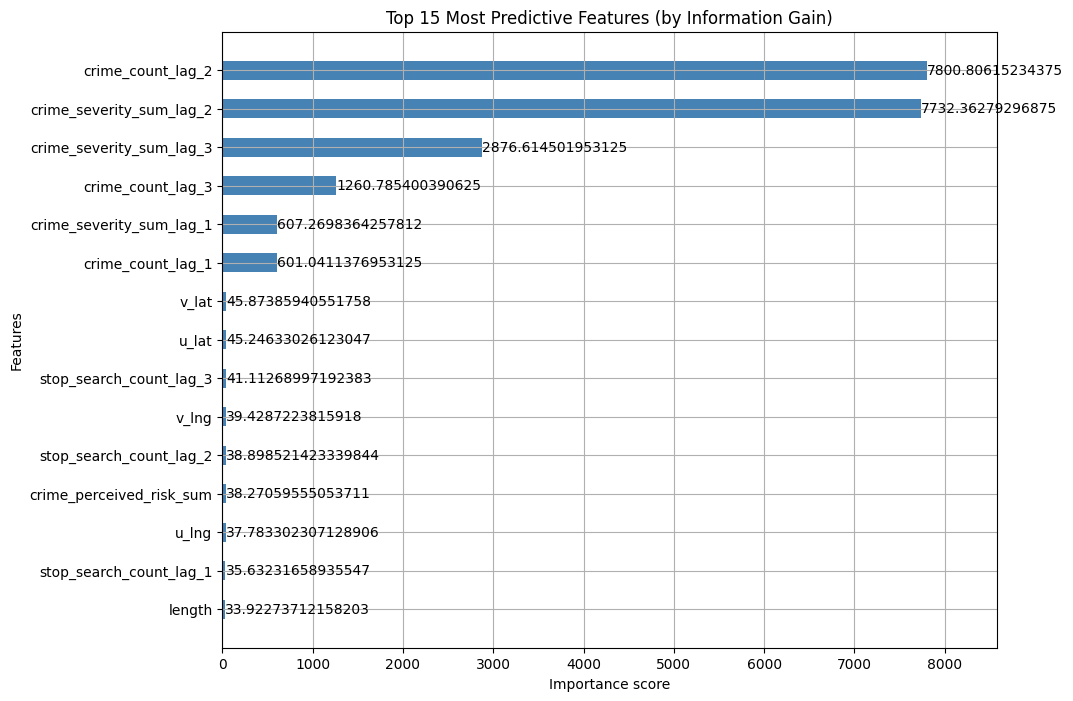


Feature Importance Rankings:
                     Feature         Gain
0          crime_count_lag_2  7800.806152
1   crime_severity_sum_lag_2  7732.362793
2   crime_severity_sum_lag_3  2876.614502
3          crime_count_lag_3  1260.785400
4   crime_severity_sum_lag_1   607.269836
5          crime_count_lag_1   601.041138
6                      v_lat    45.873859
7                      u_lat    45.246330
8    stop_search_count_lag_3    41.112690
9                      v_lng    39.428722
10   stop_search_count_lag_2    38.898521
11  crime_perceived_risk_sum    38.270596
12                     u_lng    37.783302
13   stop_search_count_lag_1    35.632317
14                    length    33.922737


,Feature,Gain
0,crime_count_lag_2,7800.806152
1,crime_severity_sum_lag_2,7732.362793
2,crime_severity_sum_lag_3,2876.614502
3,crime_count_lag_3,1260.785400
4,crime_severity_sum_lag_1,607.269836
5,crime_count_lag_1,601.041138
6,v_lat,45.873859
7,u_lat,45.246330
8,stop_search_count_lag_3,41.112690
9,v_lng,39.428722


In [12]:
feature_importance(model, X_train)

In [13]:
future_edges, future_node = predict_and_map_to_nodes(df_ml, model, X_train, latest_month='2026_05')

Predicting future risk probabilities...

Top 5 Highest Risk Nodes:
      node_id  node_safety_cost        lat       lng
0   620811891          5.896221  51.570153 -0.149616
1   620020379          5.825499  51.556520 -0.209828
2   325208571          5.668185  51.557117 -0.183605
3  7876968365          5.663664  51.544257 -0.153528
4   702390546          5.626782  51.552248 -0.170092


In [14]:
osm_tag_mapping(future_edges)

Saved OSM Tag mapping. Use this to tag your .osm.pbf file.
